In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('train.csv')
df.set_index('id', inplace = True)
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19


In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

# --- 1️⃣ Sample data to reduce memory load ---
# Change: using only 100k rows for quick testing
sample_df = df.sample(n=100_000, random_state=42)
X = sample_df.drop(columns="accident_risk")
y = sample_df["accident_risk"]

# --- 2️⃣ Identify feature types ---
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
bool_features = X.select_dtypes(include=["bool"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# --- 3️⃣ Preprocessing pipeline ---
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bool", "passthrough", bool_features),
        ("num", "passthrough", numeric_features)
    ]
)

# --- 4️⃣ Define models with lighter settings ---
models = {
    "Linear Regression": LinearRegression(),
    # Change: fewer trees for faster computation
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
}

# --- 5️⃣ Cross-validation setup ---
# Change: using 3-fold CV instead of 5-fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])
    
    # Change: use built-in 'neg_root_mean_squared_error' scorer for proper RMSE
    scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    
    # Convert to positive RMSE values
    rmse_scores = -scores
    print(f"{name} RMSE (5-fold CV on sample): {rmse_scores.mean():.5f} ± {rmse_scores.std():.5f}")

Linear Regression RMSE (5-fold CV on sample): 0.07358 ± 0.00044
Random Forest RMSE (5-fold CV on sample): 0.05672 ± 0.00043


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold

# --- 1️⃣ Sample data for speed ---
sample_df = df.sample(n=100_000, random_state=42)
X = sample_df.drop(columns="accident_risk")
y = sample_df["accident_risk"]

# --- 2️⃣ Identify features ---
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
bool_features = X.select_dtypes(include=["bool"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# --- 3️⃣ Preprocessing pipeline ---
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bool", "passthrough", bool_features),
        ("num", "passthrough", numeric_features)
    ]
)

# --- 4️⃣ Random Forest pipeline ---
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# --- 5️⃣ Hyperparameter grid for RandomizedSearch ---
param_dist = {
    "regressor__n_estimators": [50, 100, 150],
    "regressor__max_depth": [None, 10, 20, 30],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": ["auto", "sqrt", 0.5]
}

# --- 6️⃣ RandomizedSearchCV ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,  # number of parameter settings sampled
    cv=kf,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=1
)

# --- 7️⃣ Fit and find best hyperparameters ---
random_search.fit(X, y)

# --- 8️⃣ Results ---
print("Best RMSE (5-fold CV):", -random_search.best_score_)
print("Best hyperparameters:")
for key, value in random_search.best_params_.items():
    print(f"  {key}: {value}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=50; total time=   0.6s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=50; total time=   0.6s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=50; total time=   0.6s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=50; total time=   0.6s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=50; total time=   0.6s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt,

c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
40 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\pipeline.py", line 663,

Best RMSE (5-fold CV): 0.05672235401364763
Best hyperparameters:
  regressor__n_estimators: 150
  regressor__min_samples_split: 2
  regressor__min_samples_leaf: 1
  regressor__max_features: 0.5
  regressor__max_depth: 10


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from xgboost import XGBRegressor

# --- 1️⃣ Sample data for faster testing ---
sample_df = df.sample(n=100_000, random_state=42)
X = sample_df.drop(columns="accident_risk")
y = sample_df["accident_risk"]

# --- 2️⃣ Identify feature types ---
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
bool_features = X.select_dtypes(include=["bool"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# --- 3️⃣ Preprocessing pipeline ---
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bool", "passthrough", bool_features),
        ("num", "passthrough", numeric_features)
    ]
)

# --- 4️⃣ Define XGBoost model ---
model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

XGBoost RMSE (5-fold CV): 0.05671 ± 0.00047


C:\Users\szymo\AppData\Local\Temp\ipykernel_20328\11821348.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp_df.head(20), palette='viridis')


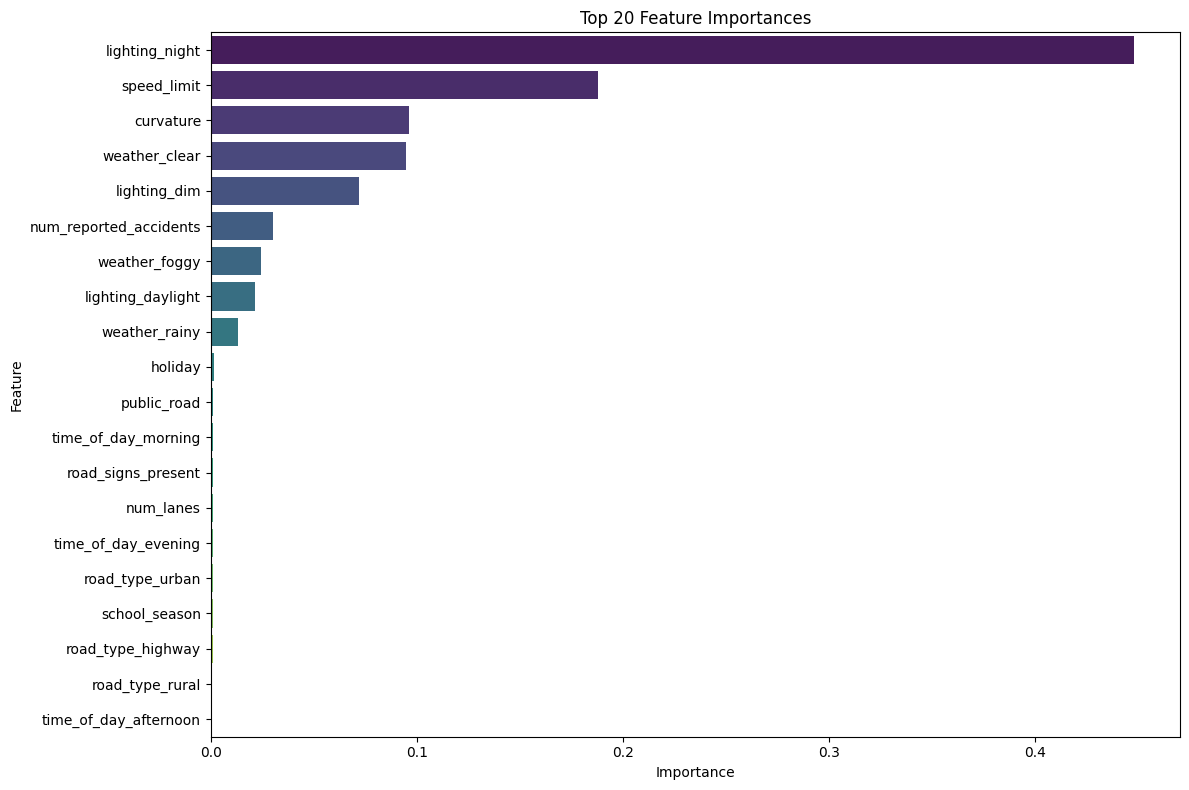

In [31]:
# --- 5️⃣ Cross-validation ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
pipeline = Pipeline([("preprocessor", preprocessor), ("regressor", model)])
scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
rmse_scores = -scores
print(f"XGBoost RMSE (5-fold CV): {rmse_scores.mean():.5f} ± {rmse_scores.std():.5f}")

# --- 6️⃣ Train on full sample ---
pipeline.fit(X, y)

# --- 7️⃣ Feature importance ---
ohe_features = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = np.concatenate([ohe_features, bool_features, numeric_features])
importances = pipeline.named_steps['regressor'].feature_importances_

feat_imp_df = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feat_imp_df.head(20), palette='viridis')
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

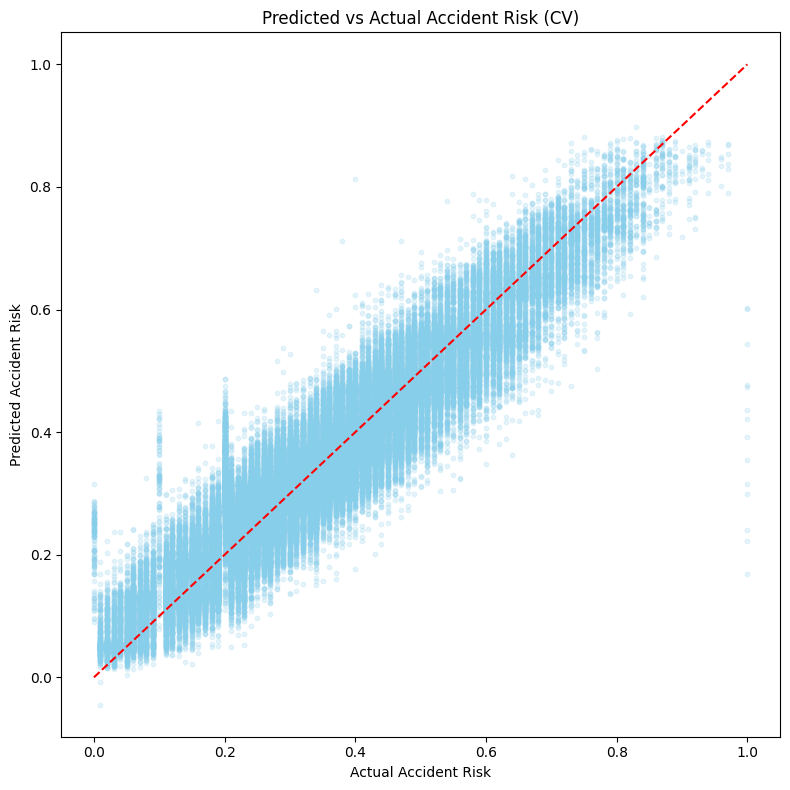

Correlation (Actual vs Predicted, CV): 0.93986
Bias (Mean Prediction Error, CV): -0.00002
RMSE (CV): 0.05673


In [32]:
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    
    y_true_all.append(y_val)
    y_pred_all.append(y_pred)

# Połącz wyniki z wszystkich foldów
y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

# Scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(y_true_all, y_pred_all, alpha=0.2, s=10, color='skyblue')
plt.plot([y_true_all.min(), y_true_all.max()], [y_true_all.min(), y_true_all.max()], 'r--')
plt.xlabel("Actual Accident Risk")
plt.ylabel("Predicted Accident Risk")
plt.title("Predicted vs Actual Accident Risk (CV)")
plt.tight_layout()
plt.show()

# Metrics
correlation = np.corrcoef(y_true_all, y_pred_all)[0, 1]
bias = np.mean(y_pred_all - y_true_all)
rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))

print(f"Correlation (Actual vs Predicted, CV): {correlation:.5f}")
print(f"Bias (Mean Prediction Error, CV): {bias:.5f}")
print(f"RMSE (CV): {rmse:.5f}")



Stacking CV RMSE: 0.05795
Stacking CV Bias: -0.00000
Stacking CV Correlation: 0.93785


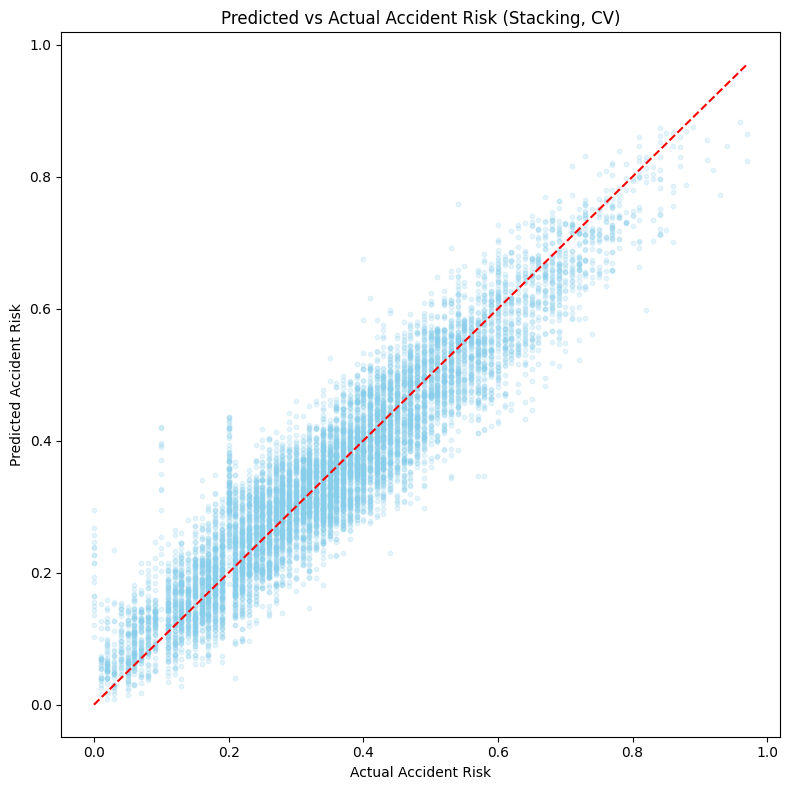

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# --- 1️⃣ Sample data (optional for speed) ---
sample_df = df.sample(n=10_000, random_state=42)
X = sample_df.drop(columns="accident_risk")
y = sample_df["accident_risk"]

# --- 2️⃣ Identify feature types ---
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
bool_features = X.select_dtypes(include=["bool"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()

# --- 3️⃣ Preprocessing ---
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("bool", "passthrough", bool_features),
    ("num", "passthrough", numeric_features)
])

# --- 4️⃣ Base models ---
base_models = [
    ("rf", RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)),
    ("xgb", xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)),
    ("lgb", lgb.LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1))
]

# --- 5️⃣ Stacking model ---
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(),
    n_jobs=-1,
    passthrough=True  # allows meta-model to see original features
)

# --- 6️⃣ Full pipeline ---
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("stacking", stack_model)
])

# --- 7️⃣ Cross-validation predictions ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X, y, cv=kf, n_jobs=-1)

# --- 8️⃣ Metrics ---
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
bias = np.mean(y_pred_cv - y)
correlation = np.corrcoef(y, y_pred_cv)[0,1]

print(f"Stacking CV RMSE: {rmse:.5f}")
print(f"Stacking CV Bias: {bias:.5f}")
print(f"Stacking CV Correlation: {correlation:.5f}")

# --- 9️⃣ Scatter plot ---
plt.figure(figsize=(8,8))
plt.scatter(y, y_pred_cv, alpha=0.2, s=10, color='skyblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Accident Risk")
plt.ylabel("Predicted Accident Risk")
plt.title("Predicted vs Actual Accident Risk (Stacking, CV)")
plt.tight_layout()
plt.show()
